In [1]:
#Importing Required Packages
import os
import numpy as np,pandas as pd
import matplotlib.pyplot as plt,seaborn as sns
from sklearn import linear_model as lm
from sklearn.model_selection import train_test_split as ttsplit
%matplotlib inline
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
#Reading The Train File And Saving It Into A DataFrame
train=pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test=pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [3]:
#Getting The Dimensions Of The Input Data
print("Train Dataframe Shape: ",train.shape)
print("Test Dataframe Shape:",test.shape)
#Getting The Names Of The Column
print(train.columns)
print(test.columns)

Train Dataframe Shape:  (891, 12)
Test Dataframe Shape: (418, 11)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [4]:
#Looking At First Few Entries Of The Train DataFrame
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
#Getting The Statistical Information
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
#Getting The Datatype Of Individual Columns
train.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
#More Information About The Train DataFrame
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
#More Information About The Test DataFrame
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


Columns With Null Values:-

1.Age

2.Cabin

3.Embarked

Out Of The Above Columns, Cabin Column Has Most Null Values.So Its Better To Remove It.

In [9]:
#Dropping The Cabin Variable
train.drop(['Cabin'],axis=1,inplace=True,errors='ignore')
test.drop(['Cabin'],axis=1,inplace=True,errors='ignore')

Plotting The Distribution In The Dataset

Text(0.5, 1.0, 'Distribution Of Survival Rates,(1-->Survived)')

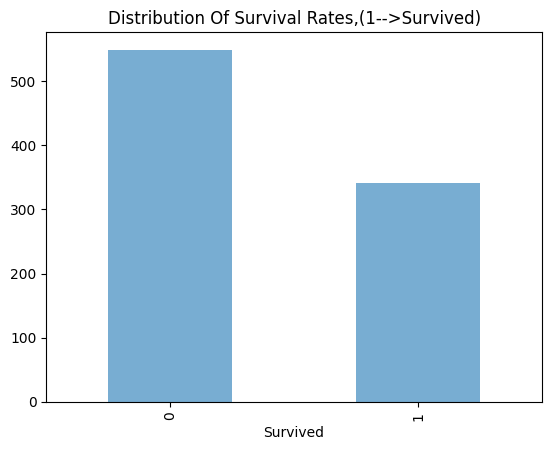

In [10]:
#Barplot For The Difference Of The Survival Rate
train.Survived.value_counts().plot(kind='bar',alpha=0.6)
plt.title("Distribution Of Survival Rates,(1-->Survived)")

Text(0.5, 1.0, 'Age Distribution')

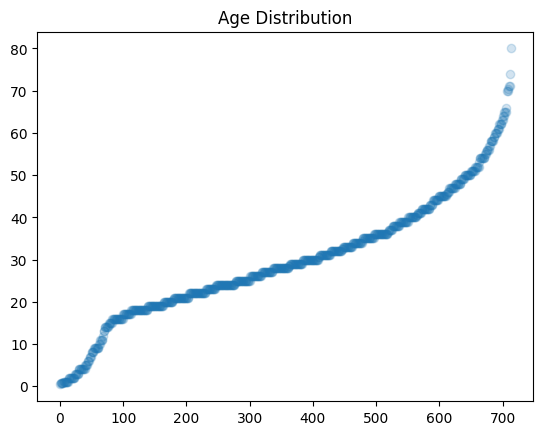

In [11]:
#Scatterplot Between Survived And Age
plt.scatter(range(train.shape[0]),np.sort(train.Age),alpha=0.2)
plt.title("Age Distribution")

Text(0.5, 1.0, 'Class Distribution')

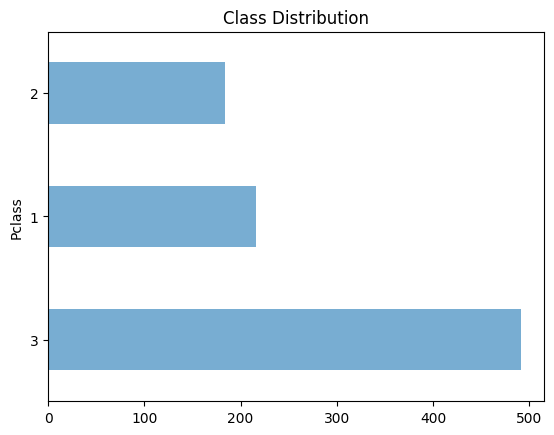

In [12]:
#Barchart For Class Distribution
train.Pclass.value_counts().plot(kind="barh",alpha=0.6)
plt.title("Class Distribution")

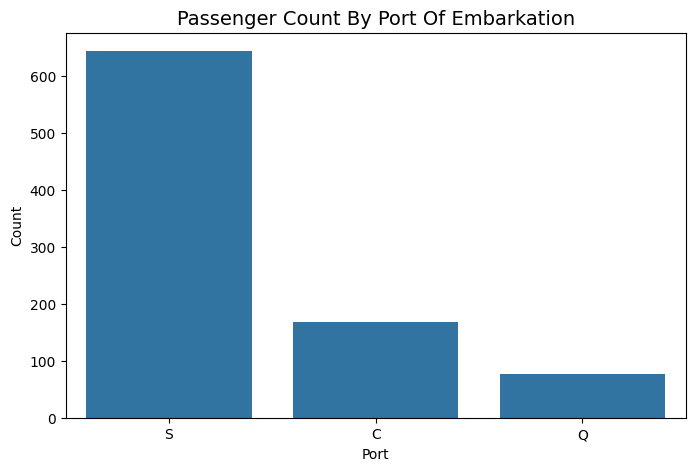

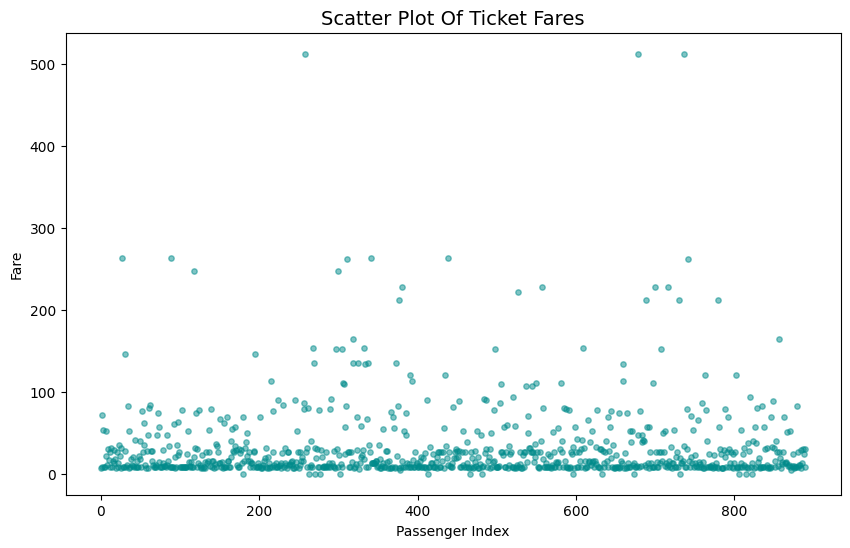

In [13]:
#Bar Graph For The Distribution Of Embarked
plt.figure(figsize=(8,5))
sns.countplot(data=train,x='Embarked')
plt.title('Passenger Count By Port Of Embarkation',fontsize=14)
plt.xlabel('Port')
plt.ylabel('Count')
plt.show()
#Scatter Plot For Fare Against Index 
plt.figure(figsize=(10,6))
plt.scatter(train.index,train['Fare'],alpha=0.5,color='darkcyan',s=15)
plt.title('Scatter Plot Of Ticket Fares',fontsize=14)
plt.xlabel('Passenger Index')
plt.ylabel('Fare')
plt.show()

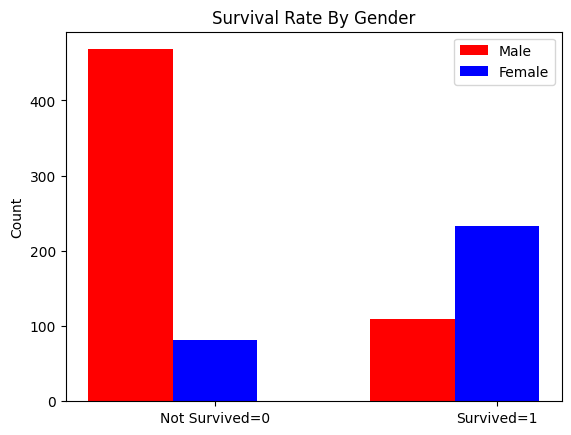

In [14]:
#Gender Distribution Among Survivors
train_male=train.Survived[train.Sex=='male'].value_counts().sort_index()
train_female=train.Survived[train.Sex=='female'].value_counts().sort_index()
idx=np.arange(2)
w=0.3
fig,ax=plt.subplots()
male=ax.bar(idx,np.array(train_male),w,color='r')
female=ax.bar(idx+w,np.array(train_female),w,color='b')
ax.set_ylabel('Count')
ax.set_title('Survival Rate By Gender')
ax.set_xticks(idx+w)
ax.set_xticklabels(('Not Survived=0','Survived=1'))
ax.legend((male[0],female[0]),('Male','Female'))
plt.show()

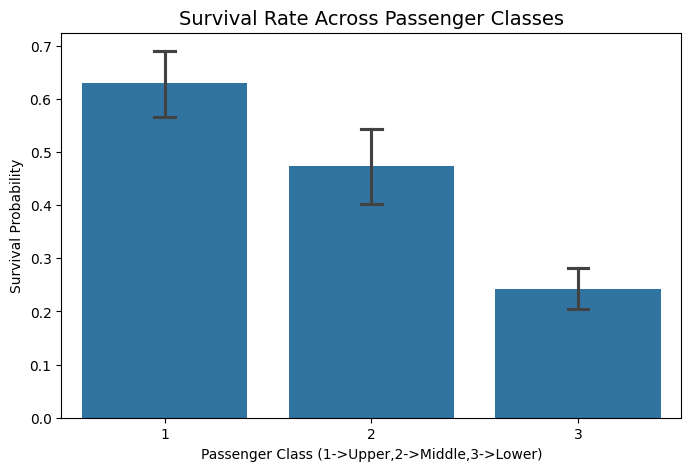

In [15]:
#Distribution Between Gender And Pclass
#Barplot In seaborn Automatically Calculates The Mean Of Survival Rate
plt.figure(figsize=(8,5))
sns.barplot(data=train,x='Pclass',y='Survived',capsize=.1)
plt.title('Survival Rate Across Passenger Classes',fontsize=14)
plt.xlabel('Passenger Class (1->Upper,2->Middle,3->Lower)')
plt.ylabel('Survival Probability')
plt.show()

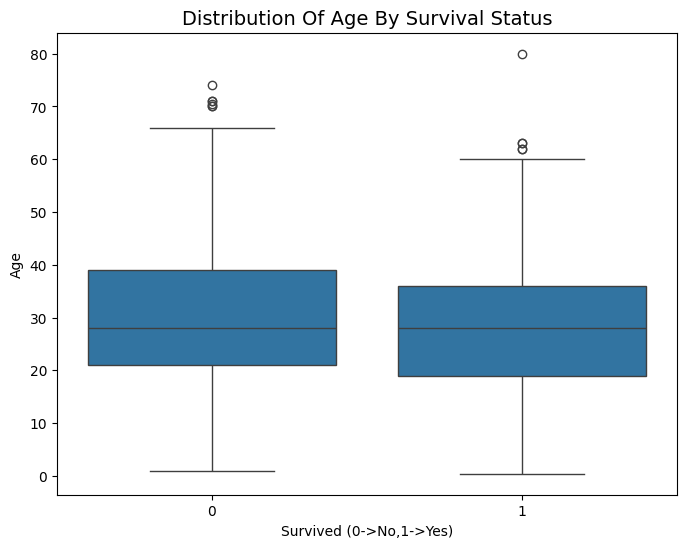

In [16]:
#Distribution Between Survival Rate And Age
plt.figure(figsize=(8,6))
sns.boxplot(data=train,x='Survived',y='Age')
plt.title('Distribution Of Age By Survival Status',fontsize=14)
plt.xlabel('Survived (0->No,1->Yes)')
plt.ylabel('Age')
plt.show()

Logistic Regression Is Suitable As We Will Predict A Binary Outcome 

In [17]:
#Getting Necessary Columns For Model Building
x_train=train[["Pclass","SibSp","Parch","Fare"]]
y_train=train["Survived"]
x_test=test[["Pclass","SibSp","Parch","Fare"]]

**Cross Validation**

We're Building The Model On A Part Of The Dataset And Then Test It On The Other Part. On Doing So, We Will Get An Idea On How Are Model Works On A New Data. This  Process Is Called Model Validation.

In [18]:
#Splitting The Training Data Into Train And Test Samples
x_train,x_test,y_train,y_test=ttsplit(x_train,y_train,test_size=0.33,random_state=42)
#Initializing The Model
clf=lm.LogisticRegression()
#Fitting The Model
clf.fit(x_train,y_train)
#Predicting
pred=clf.predict(x_test)
print(pred[:10])

[0 0 0 0 0 1 0 0 0 1]


In [19]:
#Evaluating The Accuracy Of The Model
from sklearn.metrics import accuracy_score as acc_score
acc_score(y_test,pred)

0.7084745762711865

In [20]:
#Converting Output To DataFrame
final_data={'PassengerId':test.PassengerId,'Survived':pred.astype}
submission=pd.DataFrame(data=final_data)

In [21]:
#Preparing Submission Files 
submission.to_csv('submission.csv',index=False)